In [1]:
## setup
from pathlib import Path
import sys
ROOT_PATH = (Path.cwd().parents[1]).as_posix()

if ROOT_PATH not in sys.path:
    sys.path.insert(0, ROOT_PATH)
import numpy as np
from src.model.flow_matching_model import GaussianPriorFlowMatching
from src.config import Config
import yaml
from pathlib import Path
import src.dataset as datasets
import torch
import matplotlib.pyplot as plt
from typing import Optional, Sequence, Tuple, Dict, Callable
from src.amplitude_drw_curve_utils.render_utils import (
    pick_log_freq_indices,
    extract_amplitudes,
    _std_per_frequency,
    _standardized_rayleigh_pdf,
    _standardized_rayleigh_ppf,
    _standardized_rayleigh_cdf,
    _uniform_unitvar_pdf,
    _uniform_unitvar_ppf,
    _uniform_unitvar_bounds,
    _ks_statistic,
)

# Note: "GaussianPriorFlowMatching" refers to the flow-matching base/prior
# distribution p0 (standard Gaussian noise the ODE integrates from) -- this
# is unrelated to the Rayleigh-vs-Uniform amplitude-distribution comparison
# below and is unaffected by that change.
WRAPPER_MAP = {
    "GaussianPriorFlowMatching": GaussianPriorFlowMatching,
}

def load_config(path):
    with open(path, "r") as f:
        yaml_dict = yaml.safe_load(f)
    return Config(**yaml_dict)

def load_experiment(folder_path, checkpoint_name):
    config_path = Path(ROOT_PATH)/ Path(folder_path) / Path("config.yaml")
    checkpoint_path = Path(ROOT_PATH)/ Path(folder_path) / Path(checkpoint_name)
    config = load_config(config_path)
    config.data.dataset_folder = str(Path(ROOT_PATH) / Path(config.data.dataset_folder))
    data_module = getattr(datasets, config.data.data_class)(config.data)
    wrapper = WRAPPER_MAP[config.lightning_wrapper](config)
    checkpoint = torch.load(checkpoint_path,map_location="cpu", weights_only="False")
    wrapper.load_state_dict(checkpoint["state_dict"], strict=True)
    return wrapper, data_module


/nfs/scistore20/bronsgrp/nsellam/miniforge3/envs/ml/lib/python3.11/site-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict

def _to_numpy(signals) -> np.ndarray:
    if hasattr(signals, "detach"):
        signals = signals.detach()
    if hasattr(signals, "cpu"):
        signals = signals.cpu()
    if hasattr(signals, "numpy"):
        signals = signals.numpy()
    return np.asarray(signals, dtype=float)

def _uniform_unitvar_bounds() -> float:
    return np.sqrt(3.0)

def _uniform_unitvar_ppf(p):
    p = np.clip(np.asarray(p), 1e-12, 1 - 1e-12)
    a = _uniform_unitvar_bounds()
    return (2.0 * p - 1.0) * a

def _uniform_unitvar_pdf(z):
    z = np.asarray(z)
    a = _uniform_unitvar_bounds()
    return np.where((z >= -a) & (z <= a), 1.0 / (2.0 * a), 0.0)

_RAYLEIGH_MEAN_COEF = np.sqrt(np.pi / 2.0)
_RAYLEIGH_STD_COEF = np.sqrt(2.0 - np.pi / 2.0)

def _standardized_rayleigh_pdf(z):
    z = np.asarray(z, dtype=float)
    u = z * _RAYLEIGH_STD_COEF + _RAYLEIGH_MEAN_COEF
    return np.where(u >= 0, u * np.exp(-0.5 * u * u) * _RAYLEIGH_STD_COEF, 0.0)

def _standardized_rayleigh_cdf(z):
    z = np.asarray(z, dtype=float)
    u = z * _RAYLEIGH_STD_COEF + _RAYLEIGH_MEAN_COEF
    return np.where(u >= 0, 1.0 - np.exp(-0.5 * u * u), 0.0)

def _standardized_rayleigh_ppf(p):
    p = np.clip(np.asarray(p, dtype=float), 1e-12, 1 - 1e-12)
    u = np.sqrt(-2.0 * np.log(1.0 - p))
    return (u - _RAYLEIGH_MEAN_COEF) / _RAYLEIGH_STD_COEF

def _ks_statistic(sample, cdf) -> float:
    x = np.sort(np.asarray(sample))
    n = x.size
    if n == 0:
        return 0.0
    ecdf = np.arange(1, n + 1) / n
    F = np.asarray(cdf(x))
    return float(max(np.max(ecdf - F), np.max(F - np.arange(0, n) / n)))

def _std_per_frequency(values):
    values = np.asarray(values, dtype=float)
    mu = values.mean(axis=0, keepdims=True)
    sd = values.std(axis=0, ddof=0, keepdims=True) + 1e-12
    return (values - mu) / sd, mu.squeeze(0), sd.squeeze(0)

def _pick_log_freq_indices(f, n, fmin=1e-3, fmax=0.5):
    mask = (f > 0) & (f >= fmin) & (f <= fmax)
    fpos = f[mask]
    targets = np.geomspace(fpos[0], fpos[-1], num=n)
    idx_all = np.arange(f.size)[mask]
    idx = np.clip(np.searchsorted(fpos, targets), 0, fpos.size - 1)
    return idx_all[np.unique(idx)]

def _extract_amplitudes(signals, freq_indices):
    N, T = signals.shape
    amps = np.vstack([np.abs(np.fft.rfft(signals[i]))[freq_indices] for i in range(N)])
    return amps

def render_amp_distribution_diagnostics(
    signals,
    *,
    num_freqs: int = 4,
    freq_range: Tuple[float, float] = (1e-3, 0.4),
    bins: int = 50,
    title: Optional[str] = None,
    fontsize: float = 20,
) -> Tuple[plt.Figure, Dict[str, float]]:
    signals = _to_numpy(signals)
    assert signals.ndim == 2, f"signals must be [N, T], got shape {signals.shape}"
    N, T = signals.shape

    f_full = np.fft.rfftfreq(T, d=1.0)
    idx_sel = _pick_log_freq_indices(f_full, num_freqs, fmin=freq_range[0], fmax=freq_range[1])
    f_sel = f_full[idx_sel]
    amps = _extract_amplitudes(signals, idx_sel)
    z, mu, sd = _std_per_frequency(amps)
    K = f_sel.size

    fig, axes = plt.subplots(2, K, figsize=(4.2 * K, 7.2), sharey=False)
    if K == 1:
        axes = np.array(axes).reshape(2, 1)

    zr_line = np.linspace(-4, 4, 600)
    pdf_rayl = _standardized_rayleigh_pdf(zr_line)
    zu_line = np.linspace(-2.5, 2.5, 600)
    pdf_unif = _uniform_unitvar_pdf(zu_line)

    npoints = max(60, int(np.sqrt(N) * 10))
    pp = (np.arange(1, npoints + 1) - 0.5) / npoints
    q_rayl = _standardized_rayleigh_ppf(pp)
    q_unif = _uniform_unitvar_ppf(pp)

    def cdf_unif(x):
        a = _uniform_unitvar_bounds()
        return np.where(x <= -a, 0.0, np.where(x >= a, 1.0, (x + a) / (2.0 * a)))

    ks_vals_rayl, ks_vals_unif = [], []
    legend_handles = None

    for j, f_j in enumerate(f_sel):
        z_j = z[:, j]
        cycles = f_j * T
        mu_j = float(mu[j])
        var_j = float(sd[j]) ** 2

        axA = axes[0, j]
        axA.hist(z_j, bins=bins, density=True, alpha=0.35, color="tab:blue", edgecolor="none", zorder=1)
        axA.plot(zr_line, pdf_rayl, "g:", lw=1.8, zorder=2)
        axA.plot(zu_line, pdf_unif, "k-.", lw=1.5, zorder=2)

        # ---- THE ANNOTATION BOX ----
        axA.text(
            0.97, 0.95,
            f"$\\mu = {mu_j:.3g}$\n$\\sigma^2 = {var_j:.3g}$",
            transform=axA.transAxes, ha="right", va="top",
            fontsize=max(fontsize * 0.6, 11),
            zorder=100,
            bbox=dict(boxstyle="round,pad=0.35", facecolor="0.85", edgecolor="0.4", linewidth=1.2, alpha=0.3),
        )

        if j == 0:
            axA.set_ylabel("Density", fontsize=fontsize)
        else:
            axA.tick_params(axis="y", labelleft=False)
        axA.set_xlabel("Standardized amplitude", fontsize=fontsize, labelpad=2)
        axA.grid(True, ls=":")

        d_rayl = _ks_statistic(z_j, _standardized_rayleigh_cdf)
        d_unif = _ks_statistic(z_j, cdf_unif)
        ks_vals_rayl.append(d_rayl)
        ks_vals_unif.append(d_unif)
        axA.set_title(f"{int(cycles)} cycles" if cycles > 1 else "1 cycle", fontsize=fontsize)

        axB = axes[1, j]
        q_emp = np.quantile(z_j, pp)
        qq_rayl, = axB.plot(q_rayl, q_emp, "o", ms=3.0, alpha=0.8, color="tab:green", label="QQ vs Rayleigh")
        qq_unif, = axB.plot(q_unif, q_emp, "o", ms=3.0, alpha=0.8, color="tab:orange", label="QQ vs Uniform")
        if legend_handles is None:
            legend_handles = [qq_rayl, qq_unif]

        lo = min(q_emp.min(), q_rayl.min(), q_unif.min())
        hi = max(q_emp.max(), q_rayl.max(), q_unif.max())
        pad = 0.05 * (hi - lo + 1e-9)
        lo, hi = lo - pad, hi + pad
        axB.plot([lo, hi], [lo, hi], "k:", lw=1.0)
        axB.set_xlim(lo, hi)
        axB.set_ylim(lo, hi)
        if j == 0:
            axB.set_ylabel("Empirical quantiles", fontsize=fontsize)
        else:
            axB.tick_params(axis="y", labelleft=False)
        axB.set_xlabel("Quantile", fontsize=fontsize, labelpad=4)
        axB.grid(True, ls=":")
        axA.tick_params(axis="both", labelsize=fontsize)
        axB.tick_params(axis="both", labelsize=fontsize)

    axes[0, 0].yaxis.set_label_coords(-0.20, 0.5)
    axes[1, 0].yaxis.set_label_coords(-0.20, 0.5)
    fig.tight_layout(rect=[0.02, 0.04, 1, 1])

    return fig, {
        "avg_KS_vs_Rayleigh": float(np.mean(ks_vals_rayl)) if ks_vals_rayl else np.nan,
        "avg_KS_vs_Uniform": float(np.mean(ks_vals_unif)) if ks_vals_unif else np.nan,
    }

print("render_amp_distribution_diagnostics redefined RIGHT HERE, right now -- this is the one that will run.")

render_amp_distribution_diagnostics redefined RIGHT HERE, right now -- this is the one that will run.


### Rayleigh (true DRW) model

In [3]:

## load model
folder_path = "outputs/gaussian prior - rayleigh drw"
checkpoint_name = "step=step=160500-v1.ckpt"
model_wrapper, data_module = load_experiment(folder_path, checkpoint_name)
model_wrapper.to("cuda")

## draw samples from the model and dataset
num_curves = 50000
batches = 4 
rayleigh_model_samples = torch.cat([model_wrapper.sample(num_curves // batches).cpu().squeeze() for _ in range(batches)])
dataset_samples = data_module.get_reference_curves(num_curves)


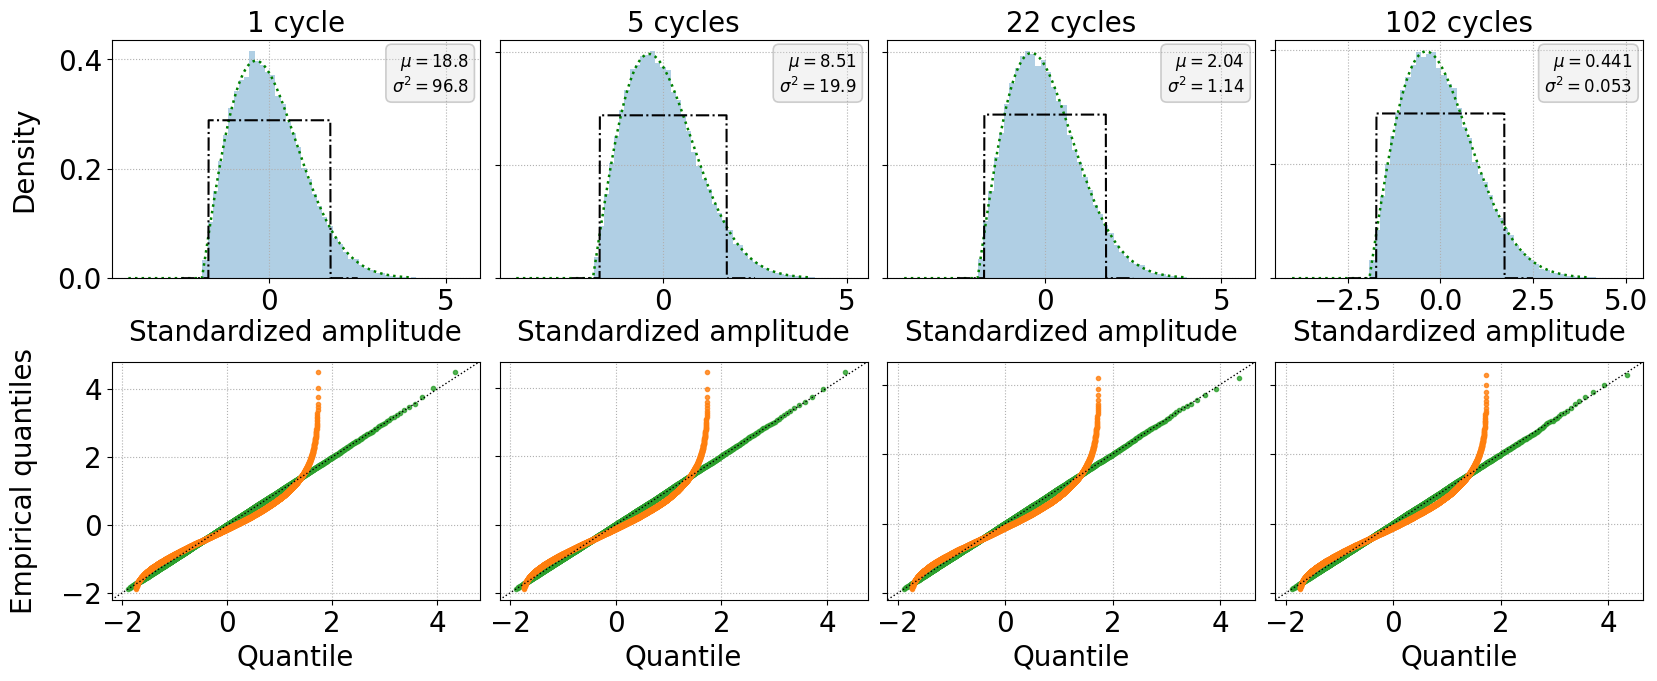

In [4]:
## render
render_amp_distribution_diagnostics(
    signals=rayleigh_model_samples.squeeze().cpu().numpy(),
    title="PSD: Model vs Target (Rayleigh / true DRW)",
    fontsize=20,
    # cmap="viridis"
    )
plt.savefig("rayleigh-model.png", dpi=500)
plt.show()


### Uniform (ablation) model

In [5]:

## load model
# folder_path = "outputs/gaussian prior - uniform drw bigger model"
folder_path = "outputs/gaussian prior - uniform drw even bigger model longer train no time domain"
checkpoint_name = "step=step=100000.ckpt"
model_wrapper, data_module = load_experiment(folder_path, checkpoint_name)
model_wrapper.to("cuda")

## draw samples from the model and dataset
num_curves = 50000
batches = 4
uniform_model_samples = torch.cat([model_wrapper.sample(num_curves // batches).cpu().squeeze() for _ in range(batches)])
dataset_samples = data_module.get_reference_curves(num_curves)


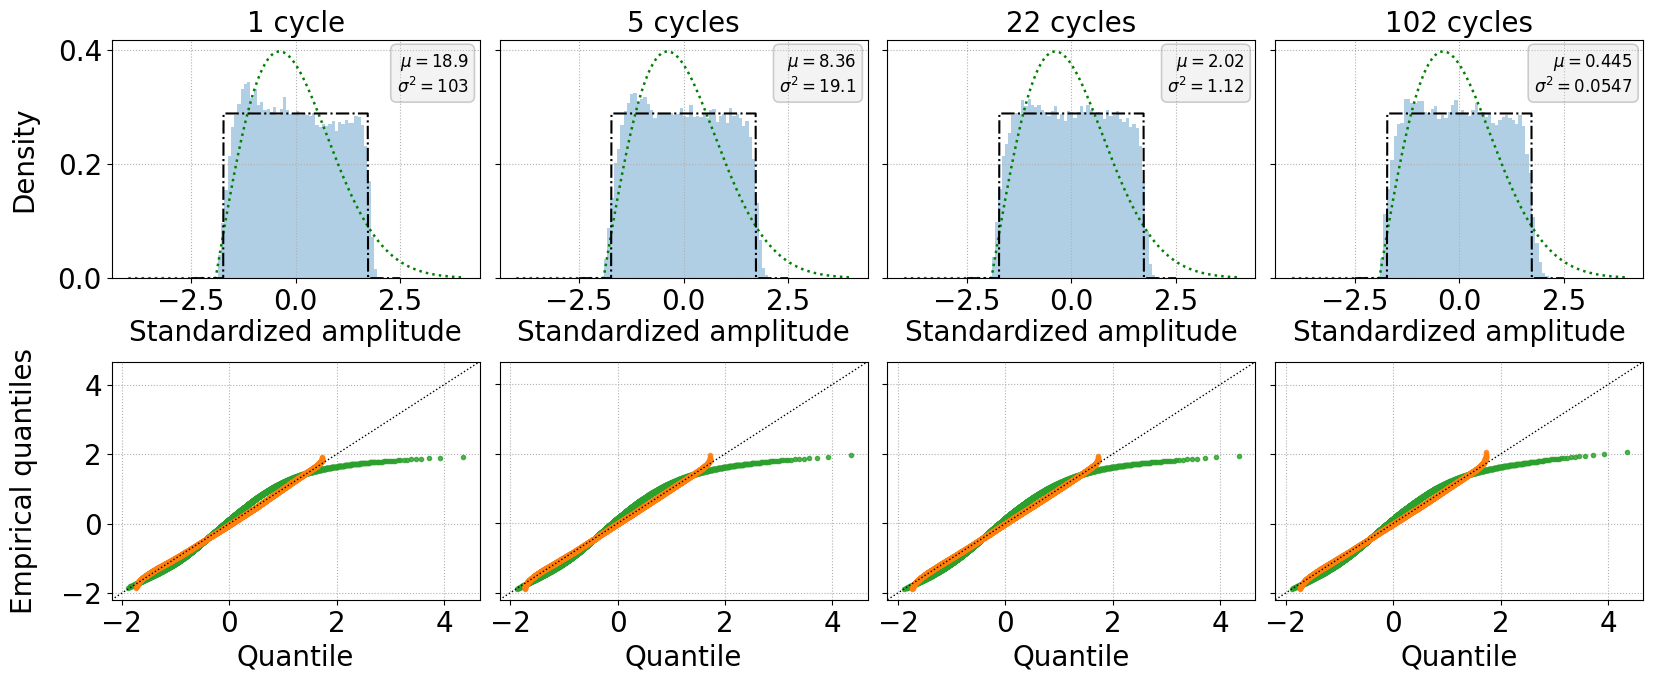

In [6]:

render_amp_distribution_diagnostics(
    signals=uniform_model_samples.squeeze().cpu().numpy(),
    title="PSD: Model vs Target (Uniform ablation)",
    fontsize=20,
    # cmap="viridis"
    )
plt.savefig("uniform-model.png", dpi=500)
plt.show()
